# Benchmark output: analysis (grp-SIS / spectral threshold)

Reads CSV/JSON from `benchmark/output/` (after `python benchmark/run_benchmark.py`) and builds tables and figures for:

- spectral reference $\tau_c \approx 1/\lambda_{\max}$, $\beta_c \approx 1/(\lambda_{\max} E[W])$;
- survival curves and empirical thresholds by recovery regime (RQ1–RQ2);
- raw runs: extinction times and late-window prevalence (RQ3).

**Path:** works when the notebook is run from the project root or from `benchmark/`.

**Interactive figures:** the first code cell tries `ipympl` (backend *widget*, pan/zoom) and otherwise falls back to *inline*. Install `ipympl` in the **same** environment as the notebook kernel, e.g. `.conda\\python.exe -m pip install ipympl`. The next cell imports matplotlib; `Agg` is used only outside IPython.

In [ ]:
# Backend: pan/zoom if `ipympl` is available in this kernel; otherwise inline (no crash).
# Project conda: .conda\\python.exe -m pip install ipympl
try:
    import ipympl  # noqa: F401 — registers the 'widget' backend

    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception as _e:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
    print("ipympl not active in this kernel → inline plots. For pan/zoom: pip install ipympl in this env.")
    print("Details:", _e)


In [23]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib

# Agg only outside Jupyter/IPython (scripts, some CI runs). In a notebook the
# interactive backend (inline/widget) remains — zoom/pan and toolbar stay available.
try:
    from IPython import get_ipython

    if get_ipython() is None:
        matplotlib.use("Agg")
except ImportError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def resolve_output_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd / "output", cwd / "benchmark" / "output"]
    for p in candidates:
        if p.is_dir() and (p / "threshold_summary.csv").is_file():
            return p
    raise FileNotFoundError(
        "No benchmark/output folder with threshold_summary.csv found. "
        f"Tried: {candidates}"
    )


OUT = resolve_output_dir()
print("Output directory:", OUT)

Output directory: C:\Dossiers\Master AI\Research Methods for AI (IM1312)\RMAI Research Project\benchmark\output


## 1. Spectral reference

In [24]:
spec_path = OUT / "spectral_reference.json"
with spec_path.open(encoding="utf-8") as f:
    spec = json.load(f)

spec_df = pd.DataFrame([spec])
display(spec_df.T)

lam = float(spec["lambda_max"])
tau_c = float(spec["tau_c"])
beta_c = float(spec["beta_c"])
ew = float(spec["recovery_mean"])

,0
num_nodes,2000.000000
num_edges,6055.000000
k_mean,6.055000
graph_seed,10001.000000
lambda_max,7.146098
tau_c,0.139937
beta_c,0.027987
recovery_mean,5.000000


## 2. Empirical thresholds (threshold_summary)

,beta_pred,beta_hat_surv_50,beta_hat_surv_50_median_boot,beta_hat_surv_50_ci_low,beta_hat_surv_50_ci_high,ratio_surv_50_over_pred,beta_hat_persist_50,recovery_regime,tau_c_pred,beta_c_pred,lambda_max
0,0.027987,0.042,0.042,0.040,0.044,1.500681,0.042,exponential,0.139937,0.027987,7.146098
1,0.027987,0.040,0.040,0.040,0.042,1.429220,0.040,power_law_tang,0.139937,0.027987,7.146098
2,0.027987,0.046,0.046,0.044,0.048,1.643602,0.046,lognormal_tang,0.139937,0.027987,7.146098


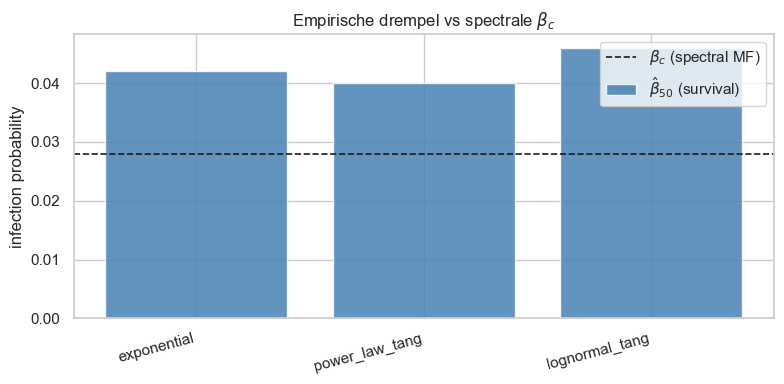

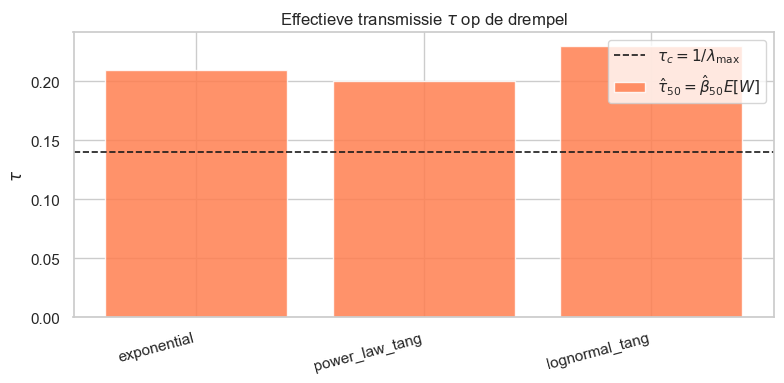

In [25]:
thr = pd.read_csv(OUT / "threshold_summary.csv")
display(thr)

if not thr.empty:
    thr["tau_hat"] = thr["beta_hat_surv_50"] * ew
    thr["tau_hat_boot_lo"] = thr["beta_hat_surv_50_ci_low"] * ew
    thr["tau_hat_boot_hi"] = thr["beta_hat_surv_50_ci_high"] * ew

    fig, ax = plt.subplots(figsize=(8, 4))
    order = thr["recovery_regime"].tolist()
    x = np.arange(len(order))
    ax.bar(x, thr["beta_hat_surv_50"], color="steelblue", alpha=0.85, label=r"$\hat\beta_{50}$ (survival)")
    ax.axhline(beta_c, color="k", ls="--", lw=1.2, label=r"$\beta_c$ (spectral MF)")
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=15, ha="right")
    ax.set_ylabel("infection probability")
    ax.set_title(r"Empirical threshold vs spectral $\beta_c$")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x, thr["tau_hat"], color="coral", alpha=0.85, label=r"$\hat\tau_{50} = \hat\beta_{50} E[W]$")
    ax.axhline(tau_c, color="k", ls="--", lw=1.2, label=r"$\tau_c = 1/\lambda_{\max}$")
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=15, ha="right")
    ax.set_ylabel(r"$\tau$")
    ax.set_title(r"Effective transmission $\tau$ at the threshold")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. Survival curves (aggregated over $\beta$)

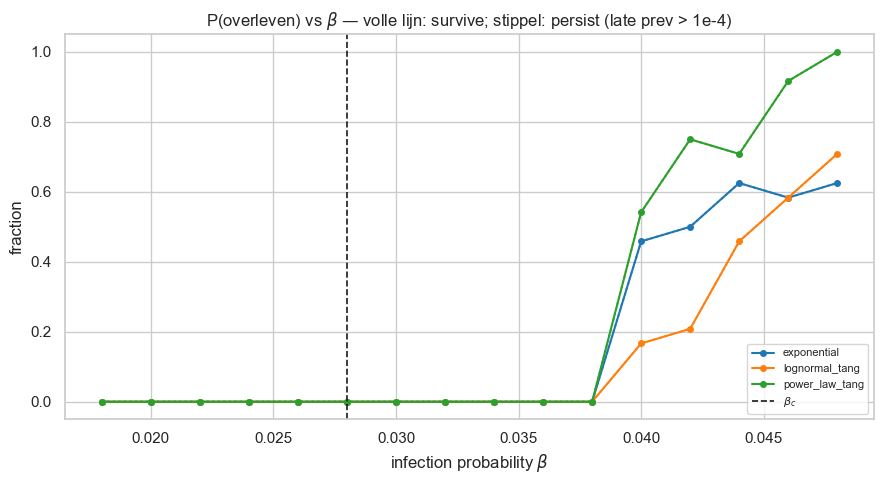

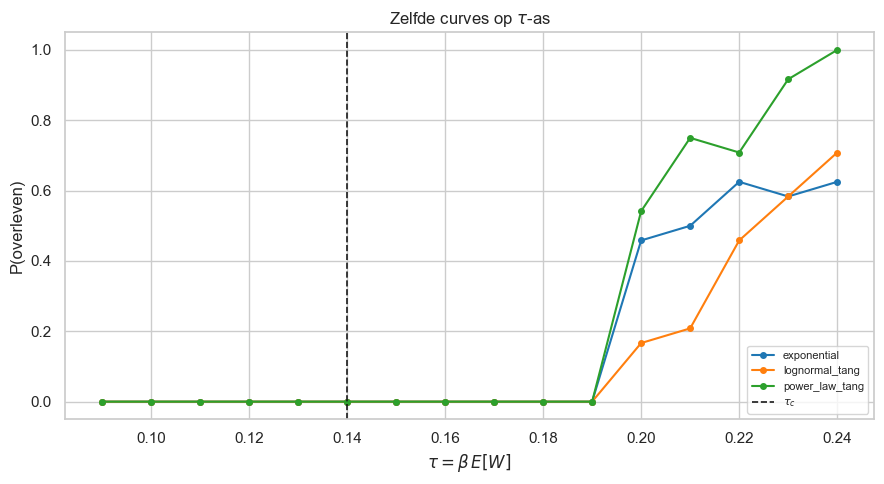

In [26]:
curve_files = sorted(OUT.glob("survival_curve_*.csv"))
if not curve_files:
    print("No survival_curve_*.csv files found.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    palette = sns.color_palette("tab10", n_colors=max(3, len(curve_files)))
    for i, path in enumerate(curve_files):
        name = path.stem.replace("survival_curve_", "")
        c = pd.read_csv(path)
        ax.plot(
            c["infection_prob"],
            c["p_survive"],
            marker="o",
            ms=4,
            label=name,
            color=palette[i % len(palette)],
        )
        if "p_persist_strict" in c.columns:
            ax.plot(
                c["infection_prob"],
                c["p_persist_strict"],
                ls=":",
                color=palette[i % len(palette)],
                alpha=0.7,
            )
    ax.axvline(beta_c, color="k", ls="--", lw=1.2, label=r"$\beta_c$")
    ax.set_xlabel(r"infection probability $\beta$")
    ax.set_ylabel("fraction")
    ax.set_title(r"P(survival) vs $\beta$ — solid: survive; dotted: persist (late prev > 1e-4)")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, path in enumerate(curve_files):
        name = path.stem.replace("survival_curve_", "")
        c = pd.read_csv(path)
        tau_axis = c["infection_prob"] * ew
        ax.plot(
            tau_axis,
            c["p_survive"],
            marker="o",
            ms=4,
            label=name,
            color=palette[i % len(palette)],
        )
    ax.axvline(tau_c, color="k", ls="--", lw=1.2, label=r"$\tau_c$")
    ax.set_xlabel(r"$\tau = \beta \, E[W]$")
    ax.set_ylabel("P(survival)")
    ax.set_title(r"Same curves on the $\tau$ axis")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

## 4. Raw runs: extinction times and prevalence (RQ3)

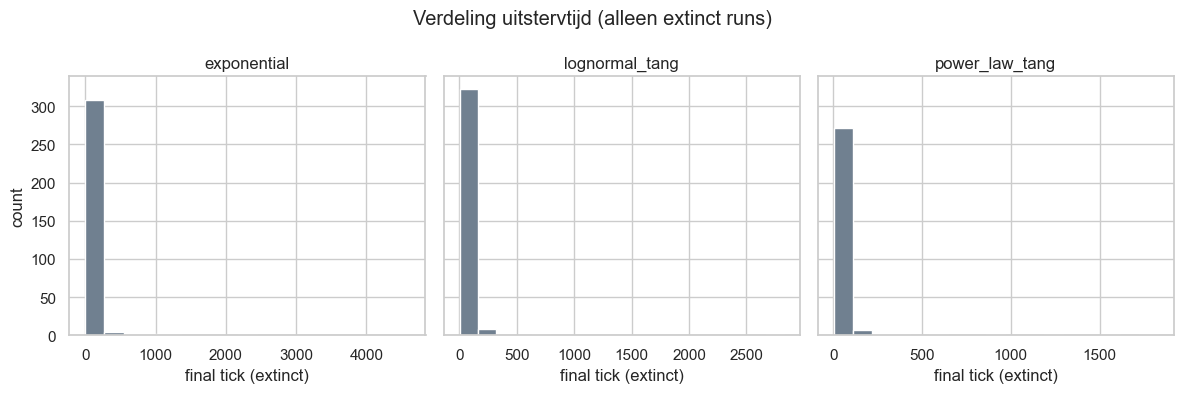

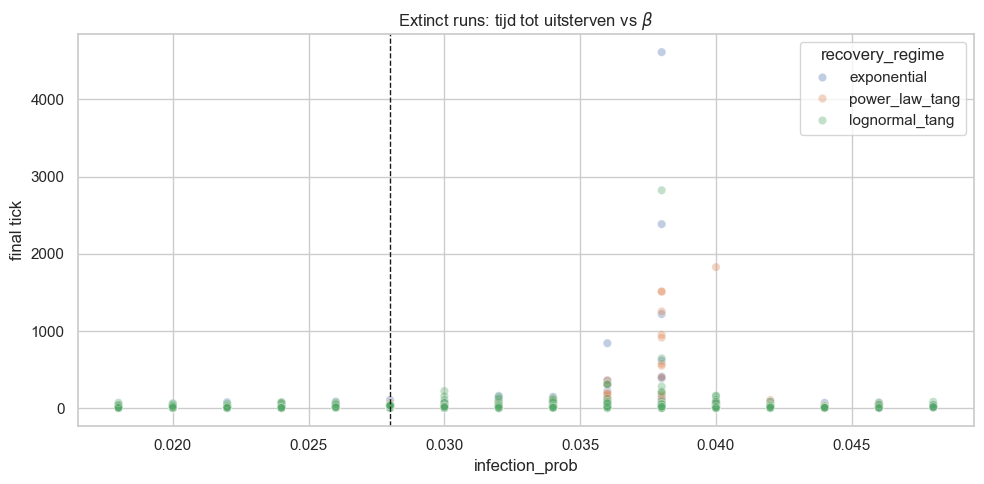

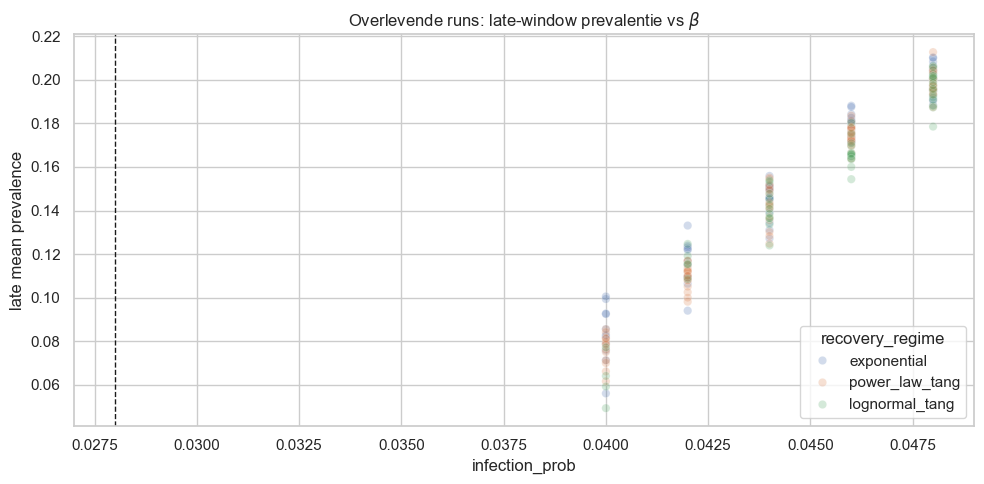

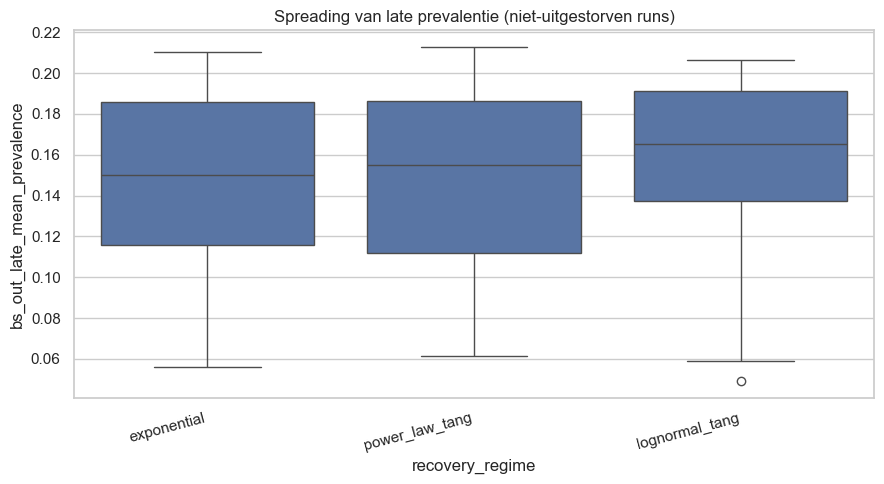

In [27]:
raw = pd.read_csv(OUT / "raw_runs.csv")
raw["survived"] = raw["bs_out_extinct"] < 0.5
raw["extinct"] = raw["bs_out_extinct"] >= 0.5

ext = raw[raw["extinct"]].copy()
surv = raw[raw["survived"]].copy()

if not ext.empty:
    regs_ext = sorted(ext["recovery_regime"].unique())
    nreg = len(regs_ext)
    fig, axes = plt.subplots(1, nreg, figsize=(4 * nreg, 4), sharey=True, squeeze=False)
    axes = axes.ravel()
    for ax, reg in zip(axes, regs_ext):
        sub = ext[ext["recovery_regime"] == reg]
        if len(sub) < 2:
            ax.text(0.5, 0.5, "few extinct runs", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.hist(
                sub["bs_out_final_tick"],
                bins=min(30, max(5, int(np.sqrt(len(sub))))),
                color="slategray",
                edgecolor="white",
            )
        ax.set_title(reg)
        ax.set_xlabel("final tick (extinct)")
    axes[0].set_ylabel("count")
    plt.suptitle("Distribution of extinction time (extinct runs only)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    sub = ext.sample(min(2000, len(ext)), random_state=0) if len(ext) > 2000 else ext
    sns.scatterplot(
        data=sub,
        x="infection_prob",
        y="bs_out_final_tick",
        hue="recovery_regime",
        alpha=0.35,
        ax=ax,
    )
    ax.axvline(beta_c, color="k", ls="--", lw=1)
    ax.set_title(r"Extinct runs: time to extinction vs $\beta$")
    ax.set_ylabel("final tick")
    plt.tight_layout()
    plt.show()

if not surv.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sub = surv.sample(min(3000, len(surv)), random_state=1) if len(surv) > 3000 else surv
    sns.scatterplot(
        data=sub,
        x="infection_prob",
        y="bs_out_late_mean_prevalence",
        hue="recovery_regime",
        alpha=0.25,
        ax=ax,
    )
    ax.axvline(beta_c, color="k", ls="--", lw=1)
    ax.set_title(r"Surviving runs: late-window prevalence vs $\beta$")
    ax.set_ylabel("late mean prevalence")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=surv,
        x="recovery_regime",
        y="bs_out_late_mean_prevalence",
        ax=ax,
    )
    ax.set_title("Spread of late prevalence (non-extinct runs)")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Summary statistics

Ratio $\hat\beta_{50}/\beta_c$: near 1 suggests rough agreement with the mean-field spectral line (exponential recovery); deviations under heavy-tailed recovery inform RQ2/RQ3.

In [28]:
if not thr.empty:
    summary = thr[[
        "recovery_regime",
        "beta_hat_surv_50",
        "beta_hat_surv_50_ci_low",
        "beta_hat_surv_50_ci_high",
        "beta_hat_persist_50",
        "ratio_surv_50_over_pred",
    ]].copy()
    summary = summary.rename(columns={"ratio_surv_50_over_pred": "ratio_hat_over_beta_c"})
    display(summary)

rows = []
for reg, g in raw.groupby("recovery_regime"):
    ex_ticks = g.loc[g["extinct"], "bs_out_final_tick"]
    rows.append(
        {
            "recovery_regime": reg,
            "n_runs": len(g),
            "fraction_extinct": float(g["extinct"].mean()),
            "median_tick_if_extinct": float(ex_ticks.median()) if len(ex_ticks) else np.nan,
        }
    )
display(pd.DataFrame(rows))

ext_rate = raw.groupby("recovery_regime")["extinct"].mean().rename("fraction_extinct")
display(ext_rate.to_frame())

,recovery_regime,beta_hat_surv_50,beta_hat_surv_50_ci_low,beta_hat_surv_50_ci_high,beta_hat_persist_50,ratio_hat_over_beta_c
0,exponential,0.042,0.040,0.044,0.042,1.500681
1,power_law_tang,0.040,0.040,0.042,0.040,1.429220
2,lognormal_tang,0.046,0.044,0.048,0.046,1.643602


,recovery_regime,n_runs,fraction_extinct,median_tick_if_extinct
0,exponential,384,0.825521,20.0
1,lognormal_tang,384,0.867188,18.0
2,power_law_tang,384,0.755208,15.5


,fraction_extinct
recovery_regime,
exponential,0.825521
lognormal_tang,0.867188
power_law_tang,0.755208
